# Fig. 3 Decoding of reward-relative position from neural activity

Many thanks to Alex Williams and Isabel Low for the open-source code that built the decoder:
https://github.com/GiocomoLab/Low_etal_2021

# Table of Contents

[Load pre-existing multiDayData](#Load-saved-multiDayData)
\
[Get continuously sampled data](#Get-continuously-sampled-data)  \
[Fit Model](#Fit-Model)  \
[Generate model shuffles](#Generate-model-shuffles)  \
[Load previously saved decoder results & start plotting](#Load-previously-saved-decoder-results)


In [10]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import dill
import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import copy

from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
sns.set_style("white")

from reward_relative import behavior as behav
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import rewardAnalysis as ra
from reward_relative import glmUtils
from reward_relative import decode

import TwoPUtils

import sklearn

save_figures = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [12]:
path_dict

{'preprocessed_root': '/data/2p_data',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2p_data/VR_Data',
 'git_repo_root': '/home/sosalab/local_repos',
 'TwoPUtils': '/home/sosalab/local_repos/TwoPUtils',
 'home': '/home/sosalab',
 'fig_dir': '/data/2p_data/fig_scratch'}

In [13]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2p_data/fig_scratch/Mar2026


## Load saved multiDayData

If you want to create a new multiDayData, use the notebook Run_dayData_class.ipynb and save the pickle first.

In [46]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment, exp_days, year='combined')
ts_key = 'dff'  # used to find place field peaks

dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multi_anim_sess', pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path, "rb"))

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans']

/data/2p_data/multi_anim_sess/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


In [16]:
# keep a subclass of multiDayData with only what we need
multiDayDataSub = dd.subclass(multiDayData)
multiDayDataSub

{3: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a973077d0>,
 5: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a9746d310>,
 7: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a97552e50>,
 8: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a97533f50>,
 10: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a97548450>,
 12: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a97523b50>,
 14: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7e9a9753fc90>}

In [17]:
del multiDayData

In [18]:
multiDayData = multiDayDataSub

## Get continuously sampled data

And find downsampled indices to match position occupancy between trial sets

[Table of contents](#Table-of-Contents)

In [19]:
days = [3, 5, 7, 8, 10, 12, 14]

celltype_inds = {}
behav_data = {}
neural_data = {}
ds = {}  # downsampled indices per session

match = 'pos'  # 'pos' or 'speed'; 'pos' used for the paper


for day in days:

    include_ans = multiDayData[day].circ_rel_stats_across_an['include_ans']
    # all_anim = ut.quick_load_multi_anim_sess(day, anim_list=dd.define_anim_list(experiment,
    #                                                                             day,
    #                                                                             year='combined'))

    
    all_anim = dd.load_multi_anim_sess(path_dict, day, an_list=dd.define_anim_list(experiment,
                                                                                day,
                                                                                year='combined'),
                                                                    subdirs = ['multi_anim_sess'])
                                                                                
    celltype_inds[day] = {}
    behav_data[day] = {}
    neural_data[day] = {}
    ds[day] = {}

    for an_i, an in enumerate(include_ans):  # include_ans):

        print("%s day %d" % (an, day))
        # Get timeseries data
        behav_data[day][an], neural_data[day][an] = glmUtils.get_timeseries_data(
            all_anim[an]['sess'],
            data_types=['trials', 'rel_pos', 'pos', 'speed', 'rewards'],
            rel_pos_type='circular',  # or 'linear'
            use_speed_thr=2,  # or None, or another value
        )

        _, celltype_inds[day][an] = dd.get_cell_class_n(
            multiDayData, day, an, verbose=False)

        y = behav_data[day][an]['rel_pos']

        # take the same number of trials from each set
        # before the switch, 0-indexed
        set0_idx = (behav_data[day][an]['trials'] <= 29).values
        set1_idx = (behav_data[day][an]['trials'] >
                    29).values  # after the switch

        relpos_edges = np.linspace(-np.pi, np.pi, 45)
        relpos_idx = np.digitize(y, relpos_edges)

        # get indices for each map's observations
        all_obs = np.arange(y.shape[0])

        # array to hold indices for downsampling
        # array to hold indices for downsampling all trials
        ds_all = np.asarray([])
        ds_0 = np.asarray([])  # array to hold indices for downsampling map 0
        ds_1 = np.asarray([])  # array to hold indices for downsampling map 1

        # match occupancy of each bin for each map
        if match == 'speed':  # option to match by speed, but we used position for the paper
            ''' Downsample to match speed and num observations '''
            speed = behav_data[day][an]['speed']
            # bin speed into 5cm/s bins
            edges = np.arange(2, np.max(speed), 5)
            speed_idx = np.digitize(speed, edges)
            bins, count = np.unique(speed_idx, return_counts=True)
            for b in bins:
                occupancy_0 = np.sum(set0_idx[speed_idx == b])
                occupancy_1 = np.sum(set1_idx[speed_idx == b])
                occupancy_all = count[bins==b]    
                idx_0 = np.where(set0_idx & (speed_idx == b))[0]
                idx_1 = np.where(set1_idx & (speed_idx == b))[0]

                if occupancy_0 == occupancy_1:
                    ds_all = np.append(ds_all, np.random.choice(all_obs[speed_idx == b], occupancy_0, replace=False))
                elif occupancy_0 > occupancy_1:
                    # need to downsample map 0 for this speed bin
                    n_timepts = occupancy_1        
                    ds_all = np.append(ds_all, np.random.choice(all_obs[speed_idx == b], n_timepts, replace=False))
                    ds_0 = np.append(ds_0, np.random.choice(idx_0, n_timepts, replace=False))
                    ds_1 = np.append(ds_1, idx_1)
                else:
                    # need to downsample map 1 for this speed bin
                    n_timepts = occupancy_0
                    ds_all = np.append(ds_all, np.random.choice(all_obs[speed_idx == b], n_timepts, replace=False))
                    ds_0 = np.append(ds_0, idx_0)
                    ds_1 = np.append(ds_1, np.random.choice(idx_1, n_timepts, replace=False)) 
            ds_all = ds_all.astype(int)
            ds_0 = ds_0.astype(int)
            ds_1 = ds_1.astype(int)
            
        elif match == 'pos':
            ''' Downsample to match the occupancy of each position bin along the track, within each trial set '''
            bins_all, count_all = np.unique(relpos_idx, return_counts=True)
            # for set 0
            # match to the minimum occupancy
            bins_0, count_0 = np.unique(relpos_idx[set0_idx], return_counts=True)
            min_occ_0 = np.min(count_0)
            
            # for set 1
            # match to the minimum occupancy
            bins_1, count_1 = np.unique(relpos_idx[set1_idx], return_counts=True)
            min_occ_1 = np.min(count_1)

            for b in np.unique(np.stack((bins_0, bins_1))):
                 
                idx_0 = np.where(set0_idx & (relpos_idx == b))[0]
                idx_1 = np.where(set1_idx & (relpos_idx == b))[0]

                ds_0 = np.append(ds_0, np.random.choice(idx_0, min_occ_0, replace=False))
                ds_1 = np.append(ds_1, np.random.choice(idx_1, min_occ_1, replace=False))
                ds_all = np.append(ds_all, np.random.choice(all_obs[relpos_idx == b], np.min(count_all), replace=False))

            ds_all = ds_all.astype(int)
            ds_0 = ds_0.astype(int)
            ds_1 = ds_1.astype(int)

        ds[day][an] = {'set 0': np.sort(ds_0), 
                       'set 1': np.sort(ds_1), 
                       'all': np.sort(ds_all)
                      }
        
    %reset_selective -f all_anim

GCAMP3 day 3
GCAMP4 day 3
GCAMP7 day 3
GCAMP11 day 3
GCAMP12 day 3
GCAMP13 day 3
GCAMP14 day 3
GCAMP15 day 3
GCAMP17 day 3
GCAMP18 day 3
GCAMP19 day 3
GCAMP3 day 5
GCAMP4 day 5
GCAMP7 day 5
GCAMP11 day 5
GCAMP12 day 5
GCAMP13 day 5
GCAMP14 day 5
GCAMP15 day 5
GCAMP17 day 5
GCAMP18 day 5
GCAMP19 day 5
GCAMP3 day 7
GCAMP4 day 7
GCAMP7 day 7
GCAMP11 day 7
GCAMP12 day 7
GCAMP13 day 7
GCAMP14 day 7
GCAMP15 day 7
GCAMP17 day 7
GCAMP18 day 7
GCAMP19 day 7
GCAMP3 day 8
GCAMP4 day 8
GCAMP7 day 8
GCAMP11 day 8
GCAMP12 day 8
GCAMP13 day 8
GCAMP14 day 8
GCAMP15 day 8
GCAMP17 day 8
GCAMP18 day 8
GCAMP19 day 8
GCAMP3 day 10
GCAMP4 day 10
GCAMP7 day 10
GCAMP11 day 10
GCAMP12 day 10
GCAMP13 day 10
GCAMP14 day 10
GCAMP15 day 10
GCAMP17 day 10
GCAMP18 day 10
GCAMP19 day 10
GCAMP3 day 12
GCAMP4 day 12
GCAMP7 day 12
GCAMP11 day 12
GCAMP12 day 12
GCAMP13 day 12
GCAMP14 day 12
GCAMP15 day 12
GCAMP17 day 12
GCAMP18 day 12
GCAMP19 day 12
GCAMP3 day 14
GCAMP4 day 14
GCAMP7 day 14
GCAMP11 day 14
GCAMP12 day 14


In [20]:
# get the relpos distribution of where reward was delivered

day_subset = [3,14]

relpos_deliv = {}
for day in day_subset:
    relpos_deliv[day] = np.array([])
    
    for an in include_ans:
        relpos_deliv[day] = np.append(relpos_deliv[day], 
                                    behav_data[day][an][behav_data[day][an]['rewards']==1]['rel_pos'].values)
        

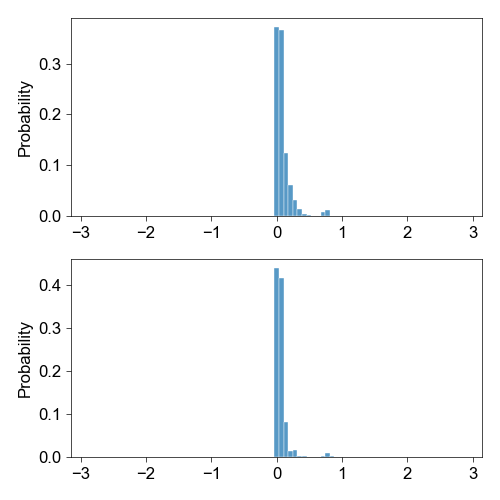

In [21]:
tinybins = np.linspace(-np.pi, np.pi, 90)
fig, ax = plt.subplots(2,1, figsize = (5,5))

# top = first switch day
sns.histplot(data=relpos_deliv[3], bins=tinybins, ax=ax[0], fill=True, stat='probability')
# bottom = last switch day
sns.histplot(data=relpos_deliv[14], bins=tinybins, ax=ax[1], fill=True, stat='probability')

ax[0].set_xlim([-np.pi, np.pi])
ax[1].set_xlim([-np.pi, np.pi])

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "allAnim_day%s_reward_delivery" % (
                ut.make_day_tag(day_subset))
                   )

In [22]:
behav_data[day][an]

,trials,rel_pos,pos,speed,rewards
0,0.0,1.780470,-2.483196,47.646111,0.0
1,0.0,1.833640,1.324815,45.607483,0.0
2,0.0,1.881875,4.779335,43.456983,0.0
3,0.0,1.933270,8.460287,41.326432,0.0
4,0.0,1.962164,10.529645,39.341837,0.0
...,...,...,...,...,...
19687,79.0,-1.443049,426.649210,45.870235,0.0
19688,79.0,-1.386974,430.665317,40.782438,0.0
19689,79.0,-1.328552,434.849459,34.517737,0.0
19690,79.0,-1.271813,438.913107,27.106757,0.0


## Fit Model

You don't need to run this if you want to just load previously saved decoder results and plot them!

[Table of contents](#Table-of-Contents)

In [23]:
from tqdm import trange
import importlib
decode = importlib.reload(decode)
REGULARIZATION = 1e-4
model = decode.CircularRegression(alpha=REGULARIZATION)

days = exp_days

# X: deconvolved events, timepoints x neurons
# y: circular position relative to reward
scores = {}
pred = {}
actual = {}

ct = 'rr'
ct_list = ['rr', 'track', 'nonreward_remap']

# cross-validate the model

for day in days:
    scores[day] = {}
    pred[day] = {}
    actual[day] = {}

    for i in trange(len(include_ans)):
        an = include_ans[i]
        scores[day][an] = {}
        pred[day][an] = {}
        actual[day][an] = {}

        y = behav_data[day][an]['rel_pos']
        y = ut.interp_nans(y.values)
        # this is a downsampled index of which samples to include to match position bin occupancies between maps
        ds_0 = ds[day][an]['set 0']
        ds_1 = ds[day][an]['set 1']
        ds_all = ds[day][an]['all']

        for ct in ct_list:

            X = neural_data[day][an][celltype_inds[day][an][ct]].T
            X[np.isnan(X)] = 0

            # get CV scores for each train and test combo
            
            # train "before", test "before"
            train0_test0_scores, train0_test0_pred, train0_test0_actual = decode.train_vs_test_blocks(
                X, y, ds_0, ds_0, model, return_prediction=True)
            # train "before", test "after"
            train0_test1_scores, train0_test1_pred, train0_test1_actual = decode.train_vs_test_blocks(
                X, y, ds_0, ds_1, model, return_prediction=True)
            # train "after", test "after"
            train1_test1_scores, train1_test1_pred, train1_test1_actual = decode.train_vs_test_blocks(
                X, y, ds_1, ds_1, model, return_prediction=True)
            # train "after", test "before"
            train1_test0_scores, train1_test0_pred, train1_test0_actual = decode.train_vs_test_blocks(
                X, y, ds_1, ds_0, model, return_prediction=True)
            # train and test on random samples from the whole session
            random_scores, random_pred, random_actual = decode.train_vs_test_blocks(
                X, y, ds_all, ds_all, model, return_prediction=True)
            
            scores[day][an][ct] = np.row_stack((train0_test0_scores, train0_test1_scores,
                                                train1_test1_scores, train1_test0_scores,
                                                random_scores))

            pred[day][an][ct] = {'train0_test0': train0_test0_pred,
                                 'train0_test1': train0_test1_pred,
                                 'train1_test1': train1_test1_pred,
                                 'train1_test0': train1_test0_pred,
                                 'random': random_pred,
                                 }

            actual[day][an][ct] = {'train0_test0': train0_test0_actual,
                                   'train0_test1': train0_test1_actual,
                                   'train1_test1': train1_test1_actual,
                                   'train1_test0': train1_test0_actual,
                                   'random': random_actual,
                                   }


100%|██████████| 11/11 [00:26<00:00,  2.44s/it]


## Generate model shuffles

takes a while! (estimated run-time on the whole dataset: ~8-9 hrs) (2.2 hrs on seahorse)

You don't need to run this if you want to just load previously saved decoder results and plot them!

[Table of contents](#Table-of-Contents)

In [24]:
# In the next step, we want to shuffle position indices as a control
N_REPEATS = 100
MAX_CELL_SHIFT = 20
MAX_POS_SHIFT = np.pi

scores_shuffle = {}
pred_shuffle = {}
actual_shuffle = {}

ct_list = ['rr', 'track', 'nonreward_remap']

for day in days:

    scores_shuffle[day] = {}
    pred_shuffle[day] = {}
    actual_shuffle[day] = {}

    for i in trange(len(include_ans)):
        an = include_ans[i]
        scores_shuffle[day][an] = {}
        pred_shuffle[day][an] = {}
        actual_shuffle[day][an] = {}

        y = behav_data[day][an]['rel_pos']
        y = ut.interp_nans(y.values) # get rid of nan values

        trials = behav_data[day][an]['trials']
        index = behav_data[day][an].index

        ds_0 = ds[day][an]['set 0']
        ds_1 = ds[day][an]['set 1']
        ds_all = ds[day][an]['all']

        ## option to use all samples instead of the downsampling
        # ds_0 = np.where((trials <= 29).values)[0]
        # ds_1 = np.where((trials > 29).values)[0] #trials.unique()[-30]).values)[0]
        # ds_all = np.asarray(index).astype(int)

        # to shuffle the position labels
        pos_shifts = (np.random.randn(N_REPEATS, 1)
                      * MAX_POS_SHIFT)

        for ct in ct_list:
            X = neural_data[day][an][celltype_inds[day][an][ct]].T
            X[np.isnan(X)] = 0

            X_all = X.copy()
            # to shuffle the neuron labels
            # cell_shifts = (np.random.randn(N_REPEATS, 1)
            #                * MAX_CELL_SHIFT).astype(int)

            # compute the shuffled scores
            shuf_train0_test0_scores = np.zeros((N_REPEATS, 10))
            shuf_train0_test1_scores = np.zeros((N_REPEATS, 10))
            shuf_train1_test0_scores = np.zeros((N_REPEATS, 10))
            shuf_train1_test1_scores = np.zeros((N_REPEATS, 10))
            shuf_train0_test1_pred = {}
            shuf_train1_test0_pred = {}
            shuf_train0_test1_actual = {}
            shuf_train1_test0_actual = {}

            shuf_train0_test0_pred = {}
            shuf_train1_test1_pred = {}
            shuf_train0_test0_actual = {}
            shuf_train1_test1_actual = {}

            shuf_random_scores = np.zeros((N_REPEATS, 10))
            shuf_random_pred = {}
            shuf_random_actual = {}

            for j in range(N_REPEATS):  # trange
                shuff_X0 = X.copy()
                shuff_X1 = X.copy()
                shuff_y0 = y.copy()
                shuff_y1 = y.copy()

                # shuffle up to the length of the whole session
                max_samp = X.shape[0]-1
                time_shift = np.random.uniform(
                    1, max_samp, X.shape[1]).astype(int)

                # train and test on shuffled position data
                shuff_X = ut.indep_roll(X_all, time_shift, axis=0)

                # train and test on random samples from the whole session
                shuf_random_scores[j, :], shuf_random_pred[j], shuf_random_actual[j] = decode.train_vs_test_blocks(shuff_X,
                                                                                                                   y, ds_all, ds_all,
                                                                                                                   model,
                                                                                                                   return_prediction=True)
                # train "before", test "before"
                shuf_train0_test0_scores[j, :], shuf_train0_test0_pred[j], shuf_train0_test0_actual[j] = decode.train_vs_test_blocks(shuff_X, y, ds_0, ds_0,
                                                                                                                                     model,
                                                                                                                                     return_prediction=True)
                # train "before", test "after"
                shuf_train0_test1_scores[j, :], shuf_train0_test1_pred[j], shuf_train0_test1_actual[j] = decode.train_vs_test_blocks(shuff_X, y, ds_0, ds_1,
                                                                                                                                     model,
                                                                                                                                     return_prediction=True)
                # train "after", test "before"
                shuf_train1_test0_scores[j, :], shuf_train1_test0_pred[j], shuf_train1_test0_actual[j] = decode.train_vs_test_blocks(shuff_X, y, ds_1, ds_0,
                                                                                                                                     model,
                                                                                                                                     return_prediction=True)
                # train "after", test "after"
                shuf_train1_test1_scores[j, :], shuf_train1_test1_pred[j], shuf_train1_test1_actual[j] = decode.train_vs_test_blocks(shuff_X, y, ds_1, ds_1,
                                                                                                                                     model,
                                                                                                                                     return_prediction=True)

            pred_shuffle[day][an][ct] = {'train0_test0': shuf_train0_test0_pred,
                                         'train0_test1': shuf_train0_test1_pred,
                                         'train1_test1': shuf_train1_test1_pred,
                                         'train1_test0': shuf_train1_test0_pred,
                                         'random': shuf_random_pred,
                                         }

            actual_shuffle[day][an][ct] = {'train0_test0': shuf_train0_test0_actual,
                                           'train0_test1': shuf_train0_test1_actual,
                                           'train1_test1': shuf_train1_test1_actual,
                                           'train1_test0': shuf_train1_test0_actual,
                                           'random': shuf_random_actual,
                                           }

            scores_shuffle[day][an][ct] = np.stack((shuf_train0_test0_scores,
                                                    shuf_train0_test1_scores,
                                                    shuf_train1_test1_scores,
                                                    shuf_train1_test0_scores,
                                                    shuf_random_scores),
                                                   axis=-1)

 55%|█████▍    | 6/11 [08:55<07:50, 94.00s/it] /home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/decode.py:90: RuntimeWarning: overflow encountered in divide
  np.mean(np.log(1 + t * tcdf / tpdf))
/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/decode.py:94: RuntimeWarning: invalid value encountered in scalar subtract
  if (self.log_like_hist_[-1] - self.log_like_hist_[-2]) < self.tol:
/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/decode.py:90: RuntimeWarning: divide by zero encountered in divide
  np.mean(np.log(1 + t * tcdf / tpdf))
100%|██████████| 11/11 [18:14<00:00, 99.45s/it] 


In [26]:
# Save!
decoder_results = {'behavior_data': behav_data,
                   'neural_data': neural_data,
                   'ds': ds,
                   'scores': scores,
                   'pred': pred,
                   'actual': actual,
                   'scores_shuffle': scores_shuffle,
                   'pred_shuffle': pred_shuffle,
                   'actual_shuffle': actual_shuffle
                   }

pkl_name = "%s_%s_decoder_results_pos-downsamp_%s.pickle" % (ut.make_anim_tag(include_ans),
                                                             ut.make_day_tag(
                                                                 exp_days),
                                                             ut.make_date_string()
                                                             )

save_res = open(os.path.join(
    path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "wb")
dill.dump(decoder_results, save_res)
# Close the pickle
save_res.close()

# Load previously saved decoder results

[Table of contents](#Table-of-Contents)

In [ ]:
# load prev saved decoder results
dt =  '20250405-1059' #used for paper: '20241117-1507'
pkl_name = "%s_%s_decoder_results_pos-downsamp_%s.pickle" % (ut.make_anim_tag(include_ans),
                                                ut.make_day_tag(exp_days),
                                               dt
                                               )

decoder_results = dill.load(open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "rb"))


In [27]:
behav_data = decoder_results['behavior_data']
neural_data = decoder_results['neural_data']
ds = decoder_results['ds']
scores = decoder_results['scores']
pred = decoder_results['pred']
actual = decoder_results['actual']
scores_shuffle = decoder_results['scores_shuffle']
pred_shuffle = decoder_results['pred_shuffle'] 
actual_shuffle = decoder_results['actual_shuffle']


## Z-score decode to the shuffle distribution

In [28]:
# across trial sets
relpos_bins = np.linspace(-np.pi, np.pi, 45)
relpos_bincenter = relpos_bins[:-1] + (relpos_bins[-1]-relpos_bins[-2])/2
N_REPEATS = 100
ct_list = ['rr', 'track', 'nonreward_remap']

N_FOLDS = 10
binwise_zscore = {}
days = exp_days

test_on_opposite_set = True # whether to test on the opposite set of trials from train

for day in days:
    binwise_zscore[day] = {}
    
    for an_i, an in enumerate(include_ans):
        binwise_zscore[day][an] = {}
        
        for ct_i,ct in enumerate(ct_list):
            binwise_score = np.zeros((2, N_FOLDS, len(relpos_bins)-1))
            binwise_score_shuf = np.zeros((2, N_REPEATS, len(relpos_bins)-1))

            binwise_zscore[day][an][ct] = np.zeros((2, len(relpos_bins)-1))

            for tset in [0,1]:
                
                # testing on the opposite trial set from the one trained
                if test_on_opposite_set:
                    test_set = np.abs(tset-1)
                else:
                    test_set=tset

                for fold in range(N_FOLDS):
                    # decode - actual
                    pointwise_score = np.cos(pred[day][an][ct][
                        f'train{tset}_test{test_set}'][fold] - actual[day][an][ct][
                        f'train{tset}_test{test_set}'][fold])

                    # bin decoder score by relative position
                    for ii, (b_start, b_end) in enumerate(zip(relpos_bins[:-1], relpos_bins[1:])):
                        # find which relative positions are in this bin
                        in_bin = ((actual[day][an][ct][
                        f'train{tset}_test{test_set}'][fold] >= b_start) & (actual[day][an][ct][
                        f'train{tset}_test{test_set}'][fold] < b_end))

                        # find the average score in this bin
                        binwise_score[tset, fold, ii] = np.nanmean(pointwise_score[in_bin])

                # for shuffle
                for j in range(N_REPEATS):
                    # concatenate across folds within each shuffle and get the error
                   
                    this_shuf = np.zeros((N_FOLDS, len(relpos_bins)-1))
                    for fold in range(N_FOLDS):
 
                        this_perm = pred_shuffle[day][an][ct][f'train{tset}_test{test_set}'][j][fold]
                        this_actual = actual_shuffle[day][an][ct][f'train{tset}_test{test_set}'][j][fold]
                        _pointwise_shuf = np.cos(this_perm - this_actual)

                        for ii, (b_start, b_end) in enumerate(zip(relpos_bins[:-1], relpos_bins[1:])):
                            # find which relative positions are in this bin
                            in_bin = ((this_actual >= b_start) & (this_actual < b_end))

                            # find the average score in this bin
                            this_shuf[fold, ii] = np.nanmean(_pointwise_shuf[in_bin])

                    # take the mean across folds for each shuffle    
                    binwise_score_shuf[tset, j, :] = np.nanmean(this_shuf, axis=0)

                # zscore the real decode score to the shuffle distribution
                binwise_zscore[day][an][ct][tset,:] = ((np.nanmean(binwise_score[tset,:,:], axis=0) - 
                                                        np.nanmean(binwise_score_shuf[tset,:,:], axis=0)
                                                       ) / np.nanstd(binwise_score_shuf[tset,:,:], axis=0))
 
    

/tmp/ipykernel_3425809/46578941.py:47: RuntimeWarning: Mean of empty slice
  binwise_score[tset, fold, ii] = np.nanmean(pointwise_score[in_bin])
/tmp/ipykernel_3425809/46578941.py:65: RuntimeWarning: Mean of empty slice
  this_shuf[fold, ii] = np.nanmean(_pointwise_shuf[in_bin])


## take the mean z-score for each cell category across animals within a day

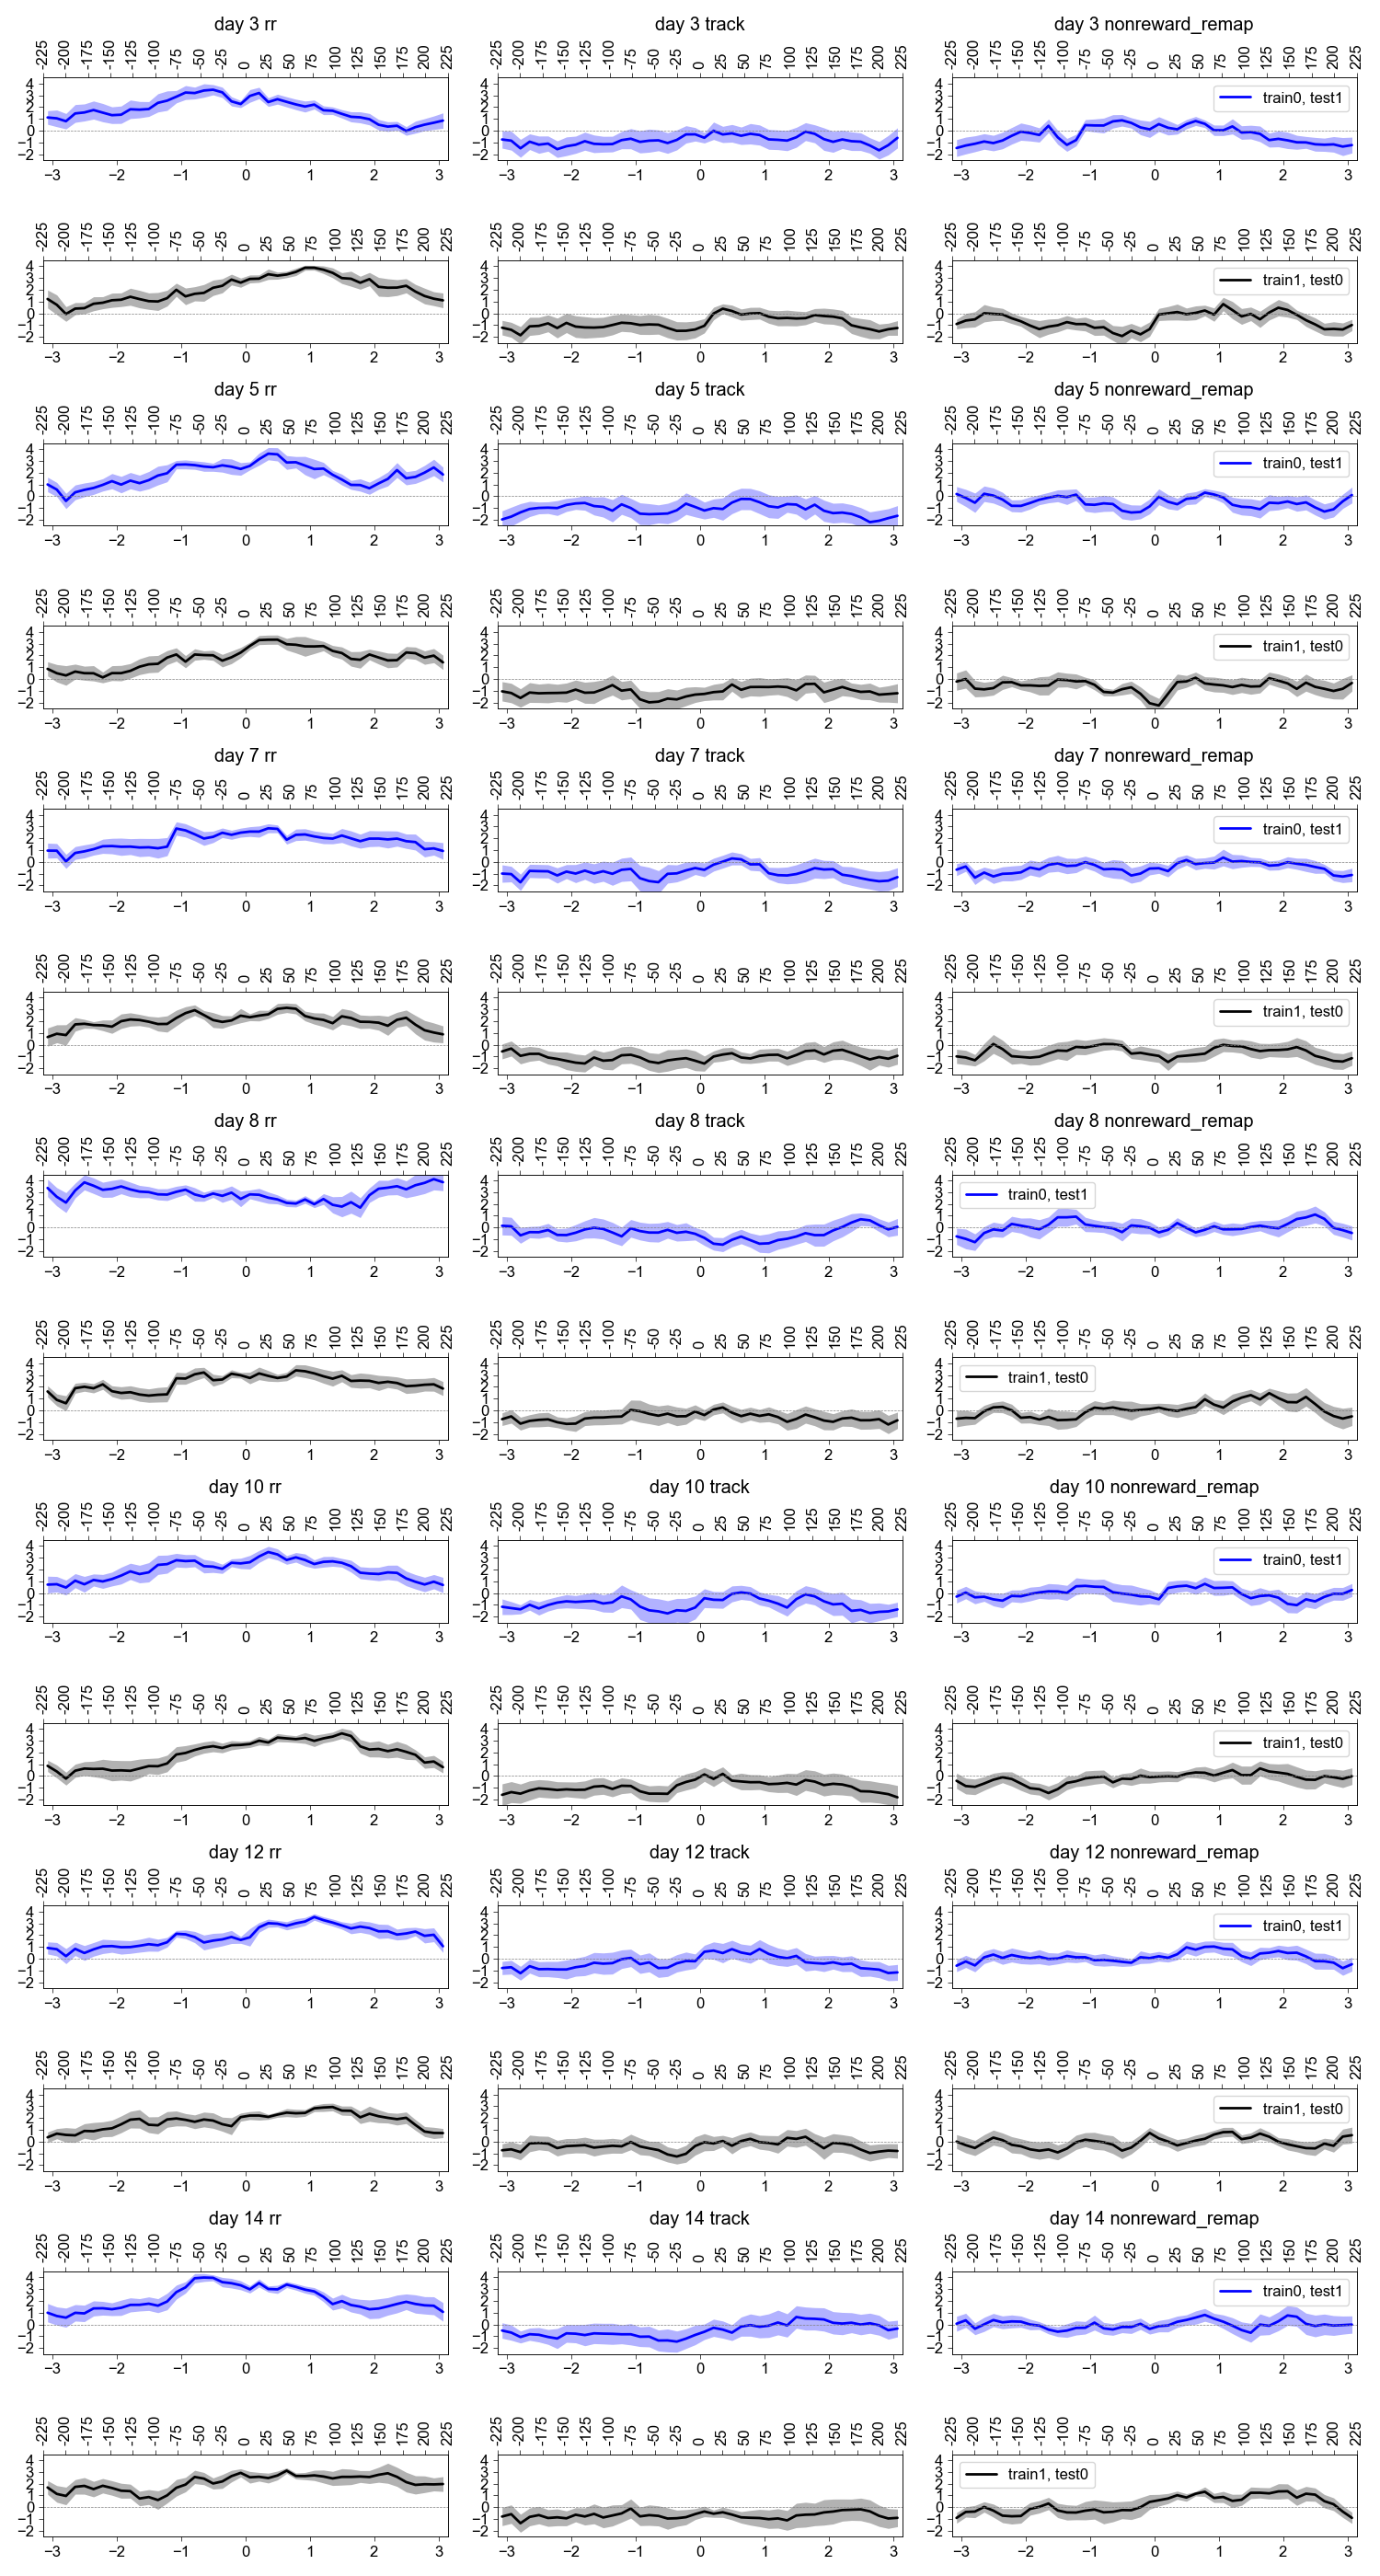

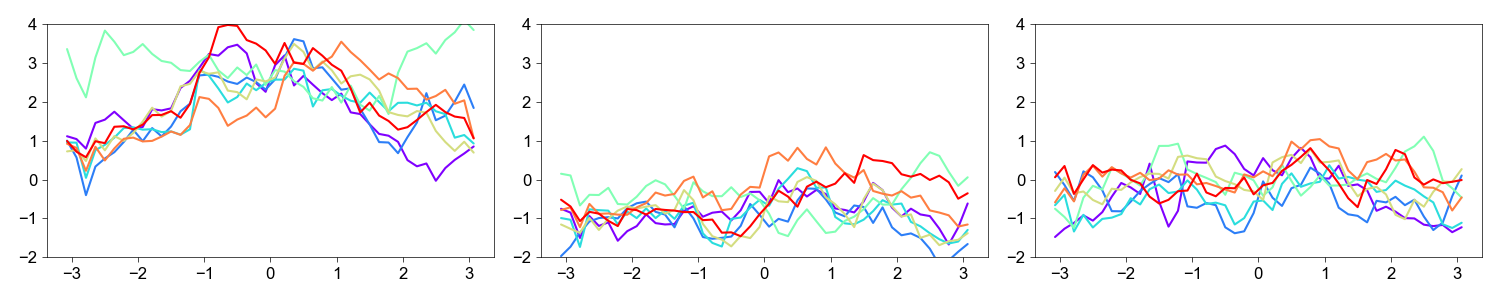

In [29]:
zscore_across_an = {}
fig, ax = plt.subplots(len(exp_days)*2, 3, figsize=(15, 4*len(exp_days)))#, sharey='row')
fig_bow, ax_bow = plt.subplots(1,3, figsize=(15,3))
day_cmap = pt.make_cmap_from_cm(len(exp_days), cmap='rainbow')

# collect for source data
df_zscore_first = {}
df_zscore_last = {}


for d_i, day in enumerate(days):
    zscore_across_an[day] = {}

    for ct_i, ct in enumerate(ct_list):
        # train set 0, test set 1
        set0_zscore = np.concatenate(
            [binwise_zscore[day][an][ct][0, :][np.newaxis, :] for an in include_ans], axis=0)
        
        #train set 1, test set 0
        set1_zscore = np.concatenate(
            [binwise_zscore[day][an][ct][1, :][np.newaxis, :] for an in include_ans], axis=0)
        
        if day==3:
            df_zscore_first[ct] = pd.DataFrame(set0_zscore, columns=relpos_bincenter)
        elif day==14:
            df_zscore_last[ct] = pd.DataFrame(set0_zscore, columns=relpos_bincenter)
            
                 
        zscore_across_an[day][ct] = {'set 0 mean': np.nanmean(set0_zscore, axis=0),
                                     'set 0 sem': ut.sem(set0_zscore, axis=0),
                                     'set 1 mean': np.nanmean(set1_zscore, axis=0),
                                     'set 1 sem': ut.sem(set1_zscore, axis=0),
                                     }
        pt.plot_mean_sem(ax[d_i*2, ct_i],
                         zscore_across_an[day][ct]['set 0 mean'],
                         zscore_across_an[day][ct]['set 0 sem'],

                         xvalues=relpos_bincenter,
                         color='b',
                         label='train0, test1'
                         )
        pt.plot_mean_sem(ax[d_i*2 + 1, ct_i],
                         zscore_across_an[day][ct]['set 1 mean'],
                         zscore_across_an[day][ct]['set 1 sem'],

                         xvalues=relpos_bincenter,
                         color='k',
                         label='train1, test0'
                         )
        
        ax_bow[ct_i].plot(relpos_bincenter,
                          zscore_across_an[day][ct]['set 0 mean'],
                         color=day_cmap[d_i,:],
                         label=day
                         )
        
        if ct_i == len(ct_list)-1:
            ax[d_i*2, ct_i].legend()
            ax[d_i*2+1, ct_i].legend()

        ax[d_i*2, ct_i].set_title('day %d %s' % (day, ct))
        
        ax[d_i*2, ct_i].hlines(0, -np.pi, np.pi, linewidth=0.5, linestyle='--', color='grey')
        ax[d_i*2 + 1, ct_i].hlines(0, -np.pi, np.pi, linewidth=0.5, linestyle='--', color='grey')
               
[[ax[_i,_j].set_yticks(np.arange(-2,5,1)) for _i in range(ax.shape[0])] for _j in range(ax.shape[1])];
[[ax[_i,_j].set_ylim([-2.5,4.5]) for _i in range(ax.shape[0])] for _j in range(ax.shape[1])];
twentyfive = spatial.dist_cm_to_rad(25, 450,0)

twiny_labels = np.arange(-225,250,25)
twiny_labels = [str(x) for x in twiny_labels]

for _i in range(ax.shape[0]):
    for _j in range(ax.shape[1]):
        
        ax2 = ax[_i,_j].twiny()
        ax2.set_xticks(np.arange(-np.pi,np.pi+twentyfive,twentyfive))
        ax2.set_xticklabels(twiny_labels, rotation=90)

[[ax[_i,_j].set_xlim([-np.pi,np.pi]) for _i in range(ax.shape[0])] for _j in range(ax.shape[1])]; 

[ax_bow[_j].set_ylim([-2,4]) for _j in range(ax.shape[1])];

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_mean_zscored_decode_same_pos-downsamp-last30set1_w25cmticks" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days))
                   )

In [30]:
df_zscore_src = pd.DataFrame()

for ct_i, ct in enumerate(ct_list):
    
    df_zscore_first[ct]['mouse_num'] = np.array([3,4,7,11,12,13,14,15,17,18,19])
    df_zscore_first[ct]['switch'] = np.ones((len(include_ans),))
    df_zscore_first[ct]['cell_category'] = np.repeat(ct, len(include_ans))
    
    df_zscore_last[ct]['mouse_num'] = np.array([3,4,7,11,12,13,14,15,17,18,19])
    df_zscore_last[ct]['switch'] = np.ones((len(include_ans),))*7
    df_zscore_last[ct]['cell_category'] = np.repeat(ct, len(include_ans))
    
    df_zscore_src = df_zscore_src.append(df_zscore_first[ct], ignore_index=True)
    df_zscore_src = df_zscore_src.append(df_zscore_last[ct], ignore_index=True)    

/tmp/ipykernel_3425809/1723480617.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_zscore_src = df_zscore_src.append(df_zscore_first[ct], ignore_index=True)
/tmp/ipykernel_3425809/1723480617.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_zscore_src = df_zscore_src.append(df_zscore_last[ct], ignore_index=True)
/tmp/ipykernel_3425809/1723480617.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_zscore_src = df_zscore_src.append(df_zscore_first[ct], ignore_index=True)
/tmp/ipykernel_3425809/1723480617.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_zscore_src = df_zscore_src.append(df_zscore_last[ct], ignore_in

In [31]:
# ut.print_full_df(df_zscore_src)

In [32]:
# ut.write_source_csv(df_zscore_src, "3c")

### Plot an example decode -- note this is from the _downsampled_ data

The data shown in the Fig. 3a example are _not_ downsampled, as the downsampling was done only for quantification purposes

i.e. to reproduce Fig. 3a, you could re-train and re-fit the decoder using all samples instead of the downsampled indices

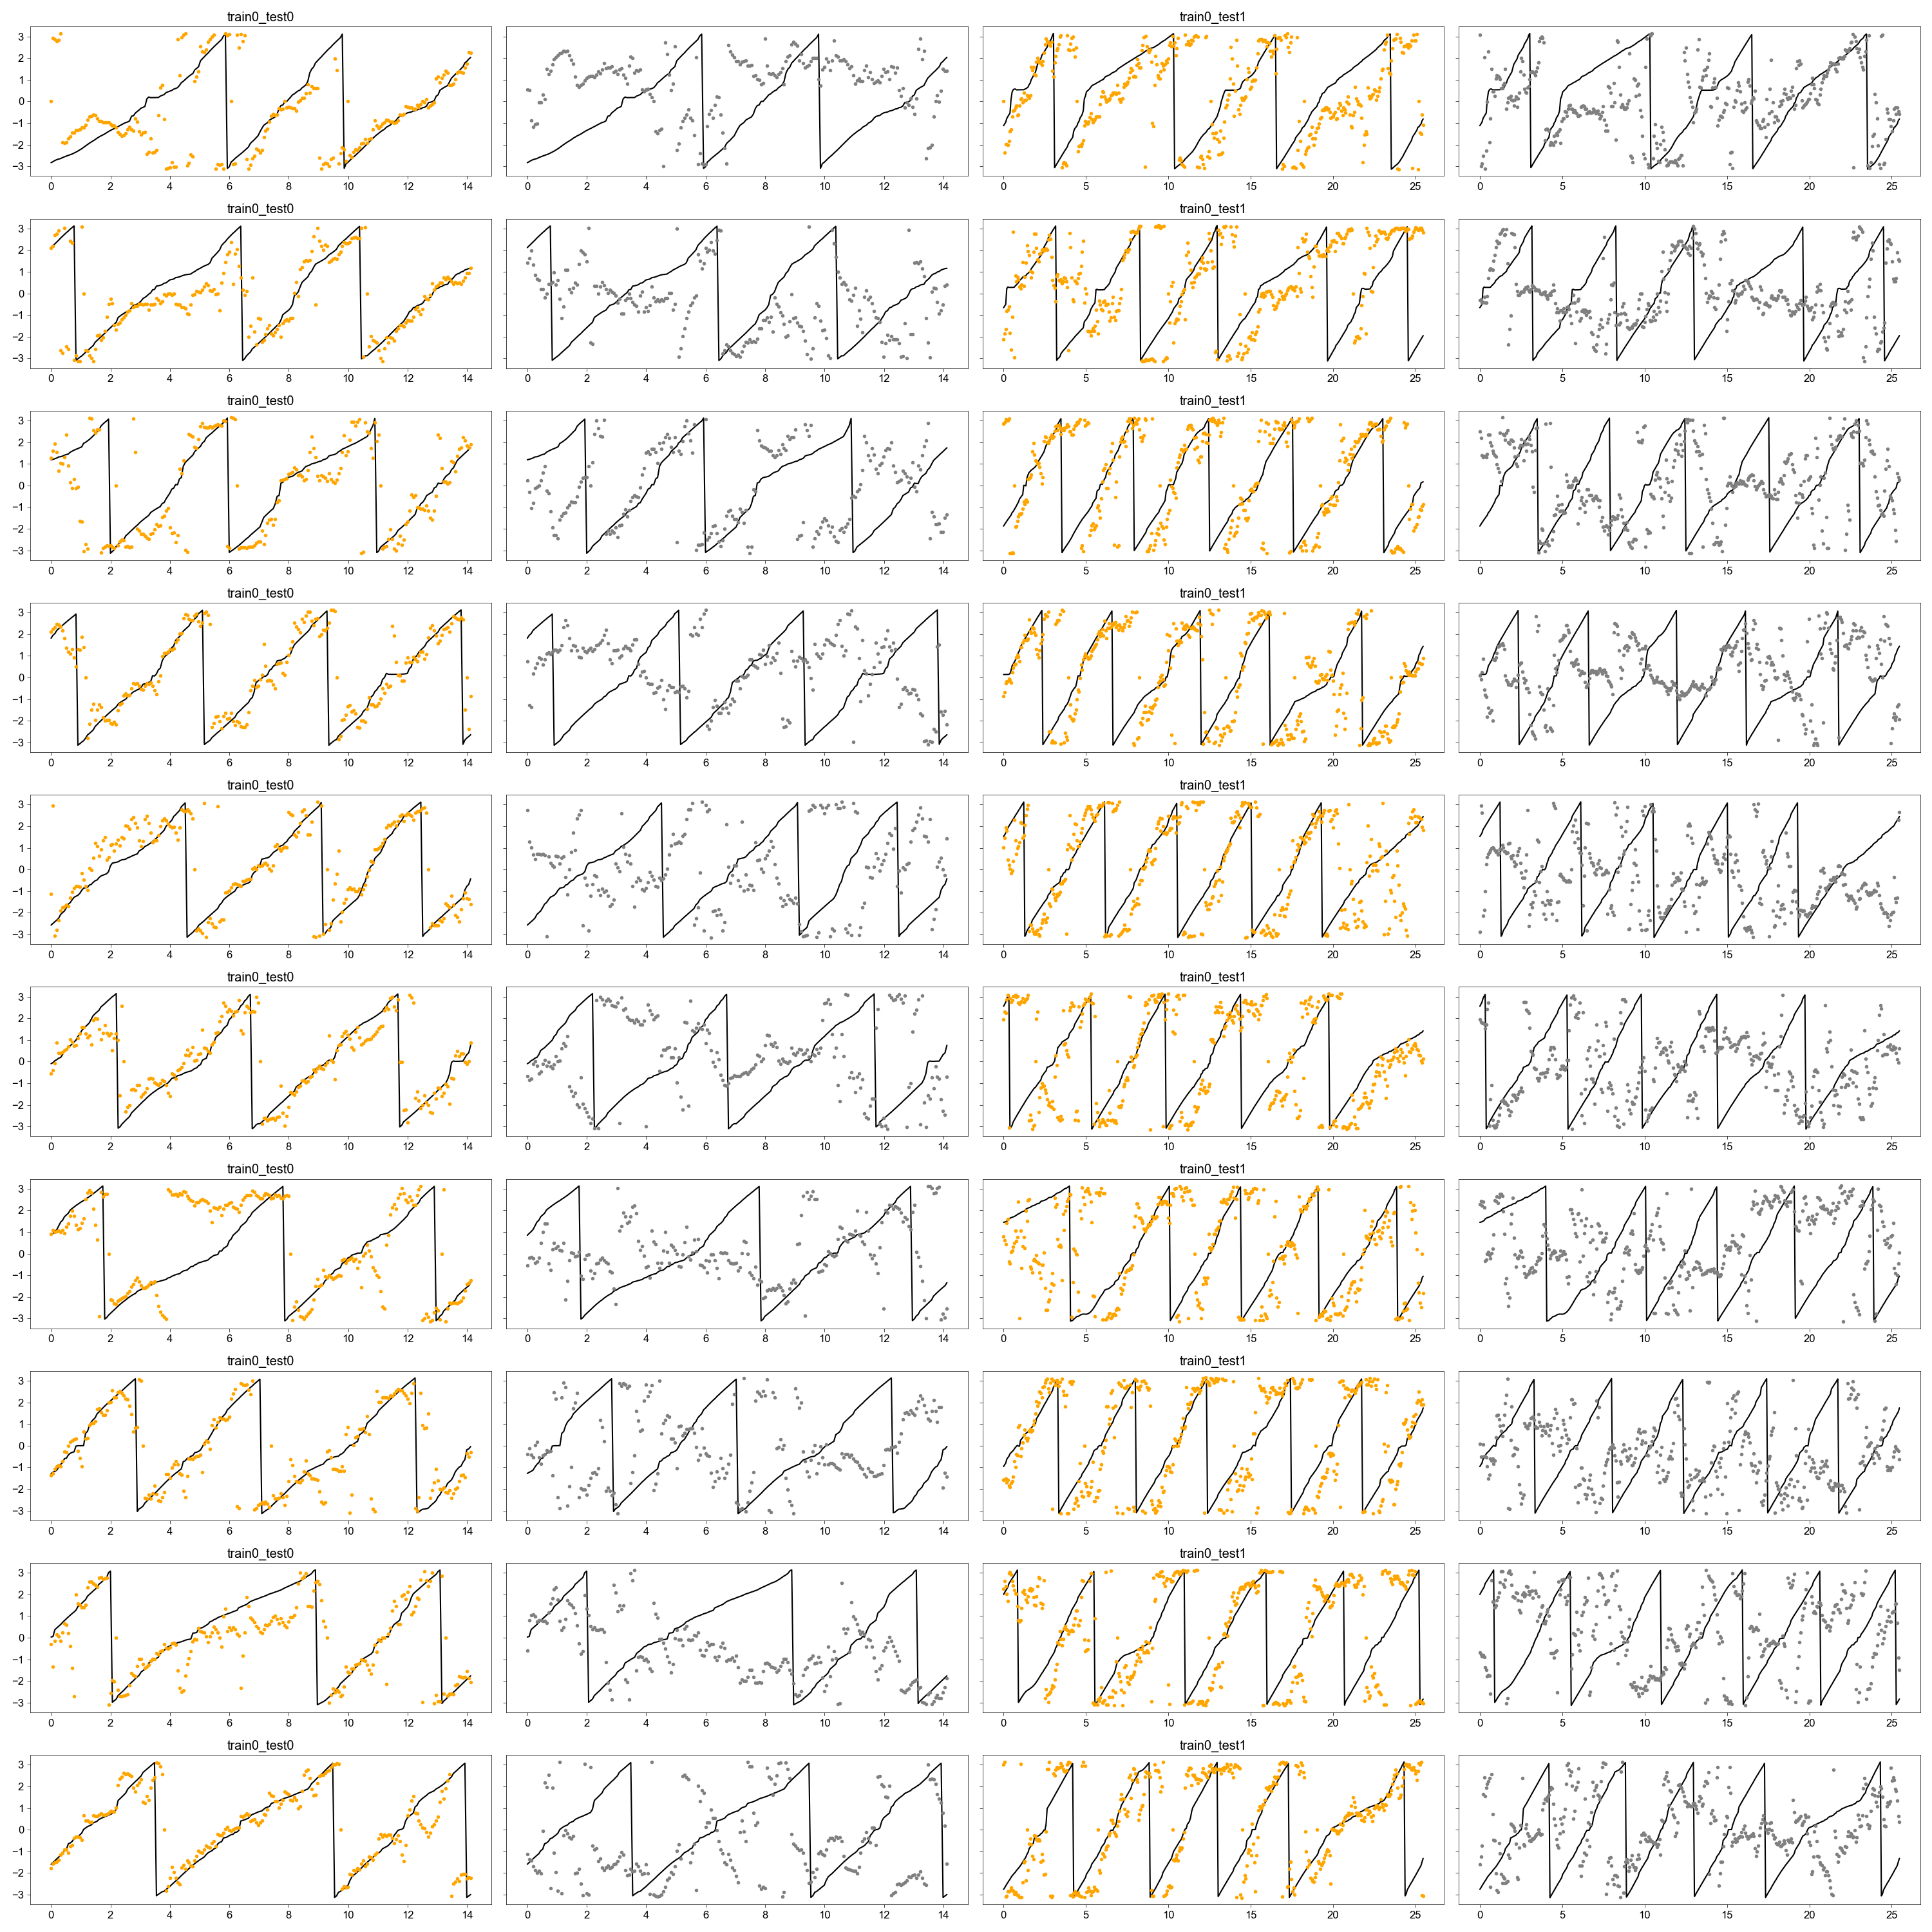

In [33]:
fig, ax = plt.subplots(N_FOLDS, 4, figsize=(30,3*N_FOLDS), sharey=True)

# rows 0,1 train0_test0_pred, train0_test0_actual
# rows 2,3 train0_test1_pred, train0_test1_actual
# rows 4,5 train1_test1_pred, train1_test1_actual
# rows 6,7 train1_test0_pred, train1_test0_actual
# rows 8,9 random_pred, random_actual

day = 14
an = 'GCAMP12'
ct = 'rr'
tset = 0
ax[0,0].set_yticks(np.arange(-3,4,1))

for fold in range(N_FOLDS):
  
    # tset = 0
    timevec = np.arange(0,len(actual[day][an][ct][
            f'train{tset}_test{tset}'][fold])*(1/15.51),(1/15.51))
    ax[fold,0].plot(timevec, actual[day][an][ct][
            f'train{tset}_test{tset}'][fold], 'k') # set 0: real reward-rel pos
    ax[fold,0].plot(timevec, pred[day][an][ct][
            f'train{tset}_test{tset}'][fold], '.',color='orange')  # full model with all cells
    #shuffle
    timevec = np.arange(0,len(actual_shuffle[day][an][ct][
            f'train{tset}_test{tset}'][j][fold])*(1/15.51),(1/15.51))
    ax[fold,1].plot(timevec, actual_shuffle[day][an][ct][
            f'train{tset}_test{tset}'][j][fold], 'k')
    ax[fold,1].plot(timevec, pred_shuffle[day][an][ct][
                f'train{tset}_test{tset}'][j][fold], '.', color='grey')
    ax[fold,0].set_title(f'train{tset}_test{tset}')

    # tset = 1
    timevec = np.arange(0,len(actual[day][an][ct][
            f'train{tset}_test{np.abs(tset-1)}'][fold])*(1/15.51),(1/15.51))
    ax[fold,2].plot(timevec, actual[day][an][ct][
            f'train{tset}_test{np.abs(tset-1)}'][fold], 'k')  # set 1
    ax[fold,2].plot(timevec, pred[day][an][ct][
            f'train{tset}_test{np.abs(tset-1)}'][fold], '.', color='orange')
    ax[fold,2].set_title(f'train{tset}_test{np.abs(tset-1)}')
    

    #shuffle
    timevec = np.arange(0,len(actual_shuffle[day][an][ct][
            f'train{tset}_test{np.abs(tset-1)}'][j][fold])*(1/15.51),(1/15.51))
    ax[fold,3].plot(timevec, actual_shuffle[day][an][ct][
            f'train{tset}_test{np.abs(tset-1)}'][j][fold], 'k')
    ax[fold,3].plot(timevec, pred_shuffle[day][an][ct][
                f'train{tset}_test{np.abs(tset-1)}'][j][fold], '.', color='grey')

# optional truncate x axis
# [[ax[_i,_j].set_xlim([0,20]) for _i in range(ax.shape[0])] for _j in range(ax.shape[1])]; 


save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_%s_actual_vs_decode_set%d_pos-downsamp-last30set1" % (
                an,day,ct,tset)
                   )   

## Get dataframe of mean scores vs. shuffle to compute stats

NOTE: There will be some slight stochasticity every time the shuffle is run,  \
so the values might not be **exactly** what they are in the paper, but they should be very close.

In [34]:
# get dataframe of mean scores

df = pd.DataFrame(columns = ['mouse', 'switch', 'day', 'ct', 'model', 'score_type','score', 'sess_id'])
decode_types = pred[days[-1]][an][ct].keys()

for day in days:
    for an_i, an in enumerate(include_ans): 
        for ct_i,ct in enumerate(ct_list):
            
            tmp_df = pd.DataFrame({'mouse': np.repeat(an,len(decode_types)*2),
                                   'day': np.repeat(day, len(decode_types)*2),
                                   'switch': np.repeat(exp_days.index(day)+1, len(decode_types)*2),
                                   'ct': np.repeat(ct, len(decode_types)*2),
                                   'model': np.tile(np.asarray(list(pred[day][an][ct].keys())),2),
                                   'score_type': np.hstack((np.repeat('real',len(decode_types)),
                                                          np.repeat('shuffle',len(decode_types)),
                                                          )),
                                   'score': np.hstack((np.nanmean(scores[day][an][ct], axis=1),
                                           np.nanmean(
                                               np.nanmean(scores_shuffle[day][an][ct], axis=1),
                                               axis=0)
                                                     )),
                                   'sess_id': np.repeat((an + '_' + str(day)), len(decode_types)*2)
                                  })
            df = df.append(tmp_df, ignore_index=True)
            
df
                             

/tmp/ipykernel_3425809/319099852.py:25: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(tmp_df, ignore_index=True)
/tmp/ipykernel_3425809/319099852.py:25: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(tmp_df, ignore_index=True)
/tmp/ipykernel_3425809/319099852.py:25: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(tmp_df, ignore_index=True)
/tmp/ipykernel_3425809/319099852.py:25: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(tmp_df, ignore_index=True)
/tmp/ipykernel_3425809/319099852.py:25: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a fu

,mouse,switch,day,ct,model,score_type,score,sess_id
0,GCAMP3,1,3,rr,train0_test0,real,0.633374,GCAMP3_3
1,GCAMP3,1,3,rr,train0_test1,real,0.103876,GCAMP3_3
2,GCAMP3,1,3,rr,train1_test1,real,0.365533,GCAMP3_3
3,GCAMP3,1,3,rr,train1_test0,real,0.410979,GCAMP3_3
4,GCAMP3,1,3,rr,random,real,0.385733,GCAMP3_3
...,...,...,...,...,...,...,...,...
2305,GCAMP19,7,14,nonreward_remap,train0_test0,shuffle,-0.002374,GCAMP19_14
2306,GCAMP19,7,14,nonreward_remap,train0_test1,shuffle,-0.000463,GCAMP19_14
2307,GCAMP19,7,14,nonreward_remap,train1_test1,shuffle,-0.003293,GCAMP19_14
2308,GCAMP19,7,14,nonreward_remap,train1_test0,shuffle,0.000483,GCAMP19_14


In [35]:
# limit to comparisons shown in plot:
df_src = df.loc[((df['model']=='train0_test0') 
               | (df['model']=='train0_test1'))]
# ut.write_source_csv(df_src, "3b")

/tmp/ipykernel_3425809/660563847.py:10: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='rr')],
/tmp/ipykernel_3425809/660563847.py:10: UserWarning: The palette list has more values (154) than needed (77), which may not be intended.
  g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='rr')],
/tmp/ipykernel_3425809/660563847.py:27: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='track')],
/tmp/ipykernel_3425809/660563847.py:27: UserWarning: The palette list has more values (154) than needed (77), which may not be intended.
  g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='track')],
/tmp/ipykernel_3425809/660563847.py:43: UserWarning: Num

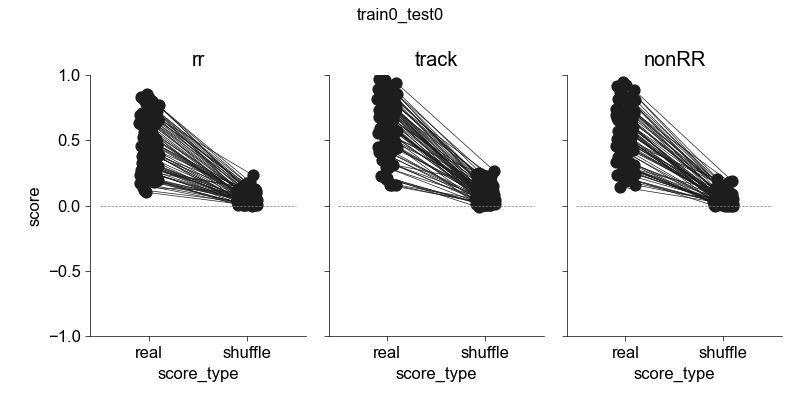

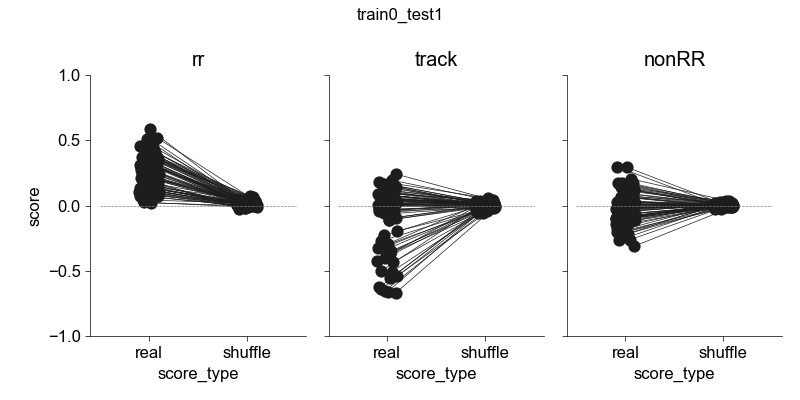

In [36]:
## Plot Fig. 3b

train = 0
model_types = [f'train{train}_test{train}', 
               f'train{train}_test{np.abs(train-1)}']

for model_type in model_types:
    fig, ax = plt.subplots(1,3, figsize=(8,4), sharey=True)

    g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='rr')],
                  x='score_type',
                  y='score',
                  hue='sess_id',
                  dodge=0.2,
                  ax=ax[0],
                    # palette='rainbow',
                  palette = pt.make_cmap_from_cm(len(df.loc[(df['model']==model_type) & (df['ct']=='rr')]), 
                                cmap='Greys_r', 
                                cmap_low=0.1, 
                                cmap_high=0.1),
                 )
    g.legend_.remove()
    plt.setp(g.collections, edgecolor="white", linewidth=0.5, alpha=0.8)
    for line in g.lines:
        line.set_linewidth(0.5)

    g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='track')],
              x='score_type',
              y='score',
              hue='sess_id',
              dodge=0.2,
              ax=ax[1],
              palette = pt.make_cmap_from_cm(len(df.loc[(df['model']==model_type) & (df['ct']=='track')]), 
                            cmap='Greys_r', 
                            cmap_low=0.1, 
                            cmap_high=0.1),
             )
    g.legend_.remove()
    plt.setp(g.collections, edgecolor="white", linewidth=0.5, alpha=0.8)
    for line in g.lines:
        line.set_linewidth(0.5)

    g=sns.pointplot(data=df.loc[(df['model']==model_type) & (df['ct']=='nonreward_remap')],
                  x='score_type',
                  y='score',
                  hue='sess_id',
                  dodge=0.2,
                  ax=ax[2],
                  palette = pt.make_cmap_from_cm(len(df.loc[(df['model']==model_type) & (df['ct']=='nonreward_remap')]), 
                                cmap='Greys_r', 
                                cmap_low=0.1, 
                                cmap_high=0.1),
                    
                 )
    g.legend_.remove()
    plt.setp(g.collections, edgecolor="white", linewidth=0.5, alpha=0.8)
    for line in g.lines:
        line.set_linewidth(0.5)

    ax[0].set_ylim([-1, 1])
    [ax[i].hlines(0,-0.5,1.5,color='grey',linestyle='--', linewidth=0.5) for i in range(ax.shape[0])]
    
    fig.suptitle(model_type)
    
    ax[0].set_title('rr')
    ax[1].set_title('track')
    ax[2].set_title('nonRR')
    sns.despine()
    
    save_figures = False
    if save_figures:
        pt.savefig(fig, fig_dir, "allSess_%s_decoder_summary_train%s_pos-downsamp-last30set1" % (
                    model_type,str(train))
                       )  

In [37]:
import pingouin

In [38]:
df_y = df.loc[((df['model']=='train0_test1'))] 

pingouin.friedman(data=df_y, dv='score', within='score_type', subject='sess_id')

,Source,W,ddof1,Q,p_unc
Friedman,score_type,0.230899,1,17.779221,0.000025


In [39]:
## Stats on train before, test before
df_00 = df.loc[((df['model']=='train0_test0'))] 
print('train0, test0')

# for RR cells df_00.loc[(df_00['ct']=='rr')]
print('RR')
print(pingouin.pairwise_ttests(data=df_00.loc[(df_00['ct']=='rr')], dv='score', within='score_type', subject='sess_id', 
                               parametric=False,  nan_policy='listwise'))
print('TR')
print(pingouin.pairwise_ttests(data=df_00.loc[(df_00['ct']=='track')], dv='score', within='score_type', subject='sess_id', 
                               parametric=False,  nan_policy='listwise'))
print('nonRR')
print(pingouin.pairwise_ttests(data=df_00.loc[(df_00['ct']=='nonreward_remap')], dv='score', within='score_type', subject='sess_id', 
                               parametric=False,  nan_policy='listwise'))
pingouin.pairwise_ttests(data=df_00, dv='score', within=['ct', 'score_type'], subject='sess_id', parametric=False, 
                        padjust='bonferroni', effsize='hedges', correction='auto', nan_policy='listwise')

train0, test0
RR
     Contrast     A        B  Paired  Parametric  W_val alternative  \
0  score_type  real  shuffle    True       False    0.0   two-sided   

          p_unc    hedges  
0  2.511764e-14  2.591803  
TR
     Contrast     A        B  Paired  Parametric  W_val alternative  \
0  score_type  real  shuffle    True       False    0.0   two-sided   

          p_unc    hedges  
0  2.511764e-14  3.252593  
nonRR
     Contrast     A        B  Paired  Parametric  W_val alternative  \
0  score_type  real  shuffle    True       False    0.0   two-sided   

          p_unc    hedges  
0  2.511764e-14  3.163052  


/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)
/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)
/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)
/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwis

,Contrast,ct,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,ct,-,nonreward_remap,rr,True,False,742.0,two-sided,1.162998e-04,3.488995e-04,bonferroni,0.263787
1,ct,-,nonreward_remap,track,True,False,434.0,two-sided,6.038503e-08,1.811551e-07,bonferroni,-0.416006
2,ct,-,rr,track,True,False,176.0,two-sided,1.724325e-11,5.172974e-11,bonferroni,-0.665014
3,score_type,-,real,shuffle,True,False,0.0,two-sided,2.511764e-14,NaN,NaN,3.201513
4,ct * score_type,nonreward_remap,real,shuffle,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,3.163052
5,ct * score_type,rr,real,shuffle,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,2.591803
6,ct * score_type,track,real,shuffle,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,3.252593


In [40]:
#sanity check that pingouin isn't doing something weird
print('RR', sp.stats.wilcoxon(df_00.loc[(df_00['ct']=='rr') & (df_00['score_type']=='real')]['score'],
                  df_00.loc[(df_00['ct']=='rr') & (df_00['score_type']=='shuffle')]['score']
                 ))
print('TR', sp.stats.wilcoxon(df_00.loc[(df_00['ct']=='track') & (df_00['score_type']=='real')]['score'],
                  df_00.loc[(df_00['ct']=='track') & (df_00['score_type']=='shuffle')]['score']
                 ))
print('nonRR', sp.stats.wilcoxon(df_00.loc[(df_00['ct']=='nonreward_remap') & (df_00['score_type']=='real')]['score'],
                  df_00.loc[(df_00['ct']=='nonreward_remap') & (df_00['score_type']=='shuffle')]['score']
                 ))

RR WilcoxonResult(statistic=0.0, pvalue=2.4628307660238145e-14)
TR WilcoxonResult(statistic=0.0, pvalue=2.4628307660238145e-14)
nonRR WilcoxonResult(statistic=0.0, pvalue=2.4628307660238145e-14)


In [41]:
## Stats on train before, test after
df_01 = df.loc[((df['model']=='train0_test1'))] 
print('train0, test1')
pingouin.pairwise_ttests(data=df_01, dv='score', within=['ct', 'score_type'], subject='sess_id', parametric=False, 
                        padjust='bonferroni', effsize='hedges', correction='auto', nan_policy='listwise')

train0, test1


/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,ct,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,ct,-,nonreward_remap,rr,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,-2.138463
1,ct,-,nonreward_remap,track,True,False,1023.0,two-sided,1.522303e-02,4.566909e-02,bonferroni,0.367069
2,ct,-,rr,track,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,1.752154
3,score_type,-,real,shuffle,True,False,936.0,two-sided,4.120728e-03,NaN,NaN,0.444972
4,ct * score_type,nonreward_remap,real,shuffle,True,False,1239.0,two-sided,1.834206e-01,5.502619e-01,bonferroni,-0.213560
5,ct * score_type,rr,real,shuffle,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,2.644048
6,ct * score_type,track,real,shuffle,True,False,1200.0,two-sided,1.264337e-01,3.793011e-01,bonferroni,-0.529985


In [42]:
## Stats on train after, test before (not shown in paper)
df_y = df.loc[((df['model']=='train1_test0'))] 
print('train1, test0')
pingouin.pairwise_ttests(data=df_y, dv='score', within=['ct', 'score_type'], subject='sess_id', parametric=False, 
                        padjust='bonferroni', effsize='hedges', correction='auto', nan_policy='listwise')

train1, test0


/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,ct,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,ct,-,nonreward_remap,rr,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,-2.216129
1,ct,-,nonreward_remap,track,True,False,974.0,two-sided,7.454554e-03,2.236366e-02,bonferroni,0.353155
2,ct,-,rr,track,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,1.817973
3,score_type,-,real,shuffle,True,False,979.0,two-sided,8.038754e-03,NaN,NaN,0.365091
4,ct * score_type,nonreward_remap,real,shuffle,True,False,1178.0,two-sided,1.010006e-01,3.030019e-01,bonferroni,-0.316721
5,ct * score_type,rr,real,shuffle,True,False,0.0,two-sided,2.511764e-14,7.535293e-14,bonferroni,2.982418
6,ct * score_type,track,real,shuffle,True,False,1092.0,two-sided,3.783073e-02,1.134922e-01,bonferroni,-0.578061
